In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

from sympy import *


def train_matrix_reconstruction(p: int,
                                H: int,
                                sigma2: float,
                                T: float,
                                num_epochs: int,
                                batch_size: int,
                                t_max = None,
                                no_target: bool = False,
                                device: str = "cuda:0"):
    """
    Symmetric case of matrix factorization.
    Train matrix factors are shared (u and u) with mini-batch GD over full epochs.

    Returns:
        u, epoch_loss_hist 
    """
    
    if t_max is None:
      t_max = num_epochs
    
    t_arr = np.linspace(0,t_max,num_epochs+1)
    tau = t_arr[1] - t_arr[0]
    
    # select device
    dev = torch.device(device if torch.cuda.is_available() else "cpu")
    sigma = sigma2 ** 0.5

    # initialize factor matrices
    u = nn.Parameter(torch.randn(H, p, device=dev) * sigma)

    # prepare identity target if needed
    if not no_target:
        delta = torch.zeros(p, p, device=dev)
        idx = torch.arange(p, device=dev)
        delta[idx, idx] = 1.0

    # SGD optimizer
    optimizer = torch.optim.SGD([u], lr=tau / T)
    epoch_loss_hist = []

    # all index pairs (i, j)
    all_idx = torch.cartesian_prod(torch.arange(p), torch.arange(p))
    num_batches = (len(all_idx) + batch_size - 1) // batch_size

    # ——— Training epochs ———
    for epoch in tqdm(range(1, num_epochs + 1)):
        epoch_loss = 0.0
        optimizer.zero_grad()

        for b in range(num_batches):
            start = b * batch_size
            end = min(start + batch_size, len(all_idx))
            batch_idx = all_idx[start:end].to(dev)

            i_batch = batch_idx[:, 0]
            j_batch = batch_idx[:, 1]

            # forward: elementwise product then sum over H
            pred = (u[:, i_batch] * u[:, j_batch]).sum(dim=0)

            # targets
            if no_target:
                tgt = torch.zeros_like(pred)
            else:
                tgt = delta[i_batch, j_batch]

            # compute half squared error
            loss = 0.5 * torch.sum((pred - tgt) ** 2)

            # accumulate gradients
            loss.backward()
            epoch_loss += loss.item()

        # parameter update
        optimizer.step()

        # record and print loss
        epoch_loss_hist.append(epoch_loss)

    # return de-tached factor and history
    return u.detach(), np.array(epoch_loss_hist), t_arr[:-1]


x, y, z, zeta = symbols('x, y, z, \\zeta')

# Standard Narayana g.f.
g = (1-z*(y+1)-sqrt(1-2*z*(y+1)+z**2*(y-1)**2))/(2*z*y)

# Our modified g.f.
h = simplify(y*g/z)
h_zeta = h.subs({'z':zeta})
u = simplify(h_zeta*(z*(1-exp(-4*x)/2)-zeta)*exp(-4*x))

Phi_zeta = simplify(diff(u, zeta))
Phi = simplify(Phi_zeta.subs({'\\zeta':z*(1-exp(-4*x))}))

# Convert to a numpy-aware function
Phi_func = lambdify((x, y, z), Phi, "numpy")

def LABEt(t,p,H,T,sigma2):
    return p/2 + p**2 * sigma2 * Phi_func(-t/T,H/p,p*sigma2)

In [ ]:
loss_hists = []
# example usage
batch_size = int(2**18)
t_max = 3
num_iters = 200
p = 512
sigma2 = 1e-2/p
H_list = [1024,512,256]
T = 1.0
for H in H_list:    
    u, loss_hist, t_arr = train_matrix_reconstruction(p, H, sigma2, T, num_iters,batch_size,t_max=t_max,no_target=False)
    loss_hists.append(loss_hist)

100%|██████████| 200/200 [00:17<00:00, 11.44it/s]


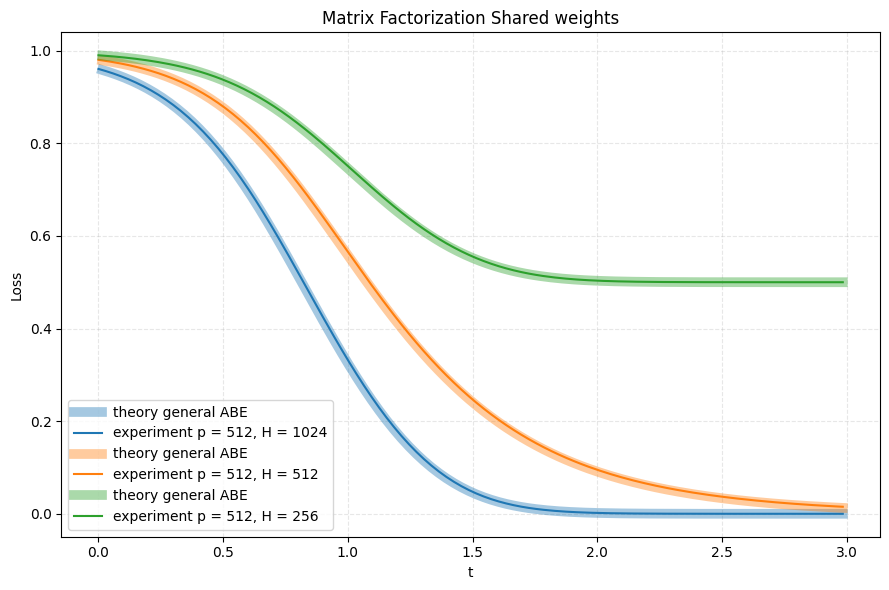

In [ ]:
plt.figure(figsize=(9, 6))
for i,H in enumerate(H_list):
    theory_loss = LABEt(t_arr,p,H,T,sigma2)
    line, = plt.plot(t_arr, theory_loss/(p/2),label=f'theory general ABE',linewidth=7,alpha=0.4)
    plt.plot(t_arr, loss_hists[i]/(p/2), color = line.get_color(), label=f'experiment p = {p}, H = {H}')

#plt.axhline(1,color='black',linewidth=2,alpha=0.8,label='target loss p/2')
#plt.yscale('log')
#plt.xscale('log')
plt.xlabel('t')
plt.ylabel('Loss')
plt.legend(loc="lower left")
plt.title(f'Matrix Factorization Shared weights')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()